# Laboratorio 1 — Introducción a Machine Learning
## Versión **docente**

**Curso:** Machine Learning (EIN143A25) · Paralelo 701  
**Fecha:** Miércoles 5 de agosto de 2026 · Sesión 1 de 17  
**Bloques:** 6-8 (11:40-13:40) · Lab. Central 114  
**Unidad 1:** Fundamentos y Preparación

**Objetivo:** salir de esta sesión con el ambiente funcionando, un dataset real explorado y un modelo
entrenado end-to-end — *sin* haber visto todavía la teoría del algoritmo. La pregunta final
*"¿por qué esto no basta?"* es el gancho hacia toda la Unidad 1.

> Esta versión trae todo el código ejecutado, los outputs y las **notas de conducción** de cada
> actividad. La versión de estudiante tiene las mismas explicaciones sin código.

---
## Bloque 6 · 11:40-12:15 · Ambiente y metodología

### 1. Verificación del ambiente · 11:40-11:55 (15 min)

Cada estudiante ejecuta esto en su equipo del laboratorio. Es el primer filtro: si algo falta,
se resuelve ahora y no a mitad de clase.

In [1]:
import sys
print(sys.version)          # Python 3.x

import sklearn, pandas, numpy, matplotlib
for lib in (sklearn, pandas, numpy, matplotlib):
    print(lib.__name__, lib.__version__)

3.9.6 (default, May 22 2026, 11:13:45) 
[Clang 21.0.0 (clang-2100.1.1.101)]


sklearn 1.6.1
pandas 2.3.3
numpy 2.0.2
matplotlib 3.9.4


> **Nota docente**  
> - Plan B si algo falla: ambiente de respaldo en la nube (Google Colab) — tener el link listo *antes* de la clase.  
> - Verificar también que Jupyter abre y ejecuta una celda (no basta con que Python importe).

### 2. Metodología de trabajo del curso · 11:55-12:05 (10 min)

- **Estructura de carpetas** sugerida para el semestre:
  ```
  ML-2026-2/
  ├── clases/        # notebooks de cada sesión
  ├── actividades/   # AP entregables
  └── datos/         # datasets locales
  ```
- **Sistema de tareas (25% de la nota):** las Actividades Prácticas se implementan como **3 tareas**
  durante el semestre, enviadas por el profesor; cada una condensa lo visto en clases hasta ese punto.
  No hay entregables semanales de laboratorio.
- **Convención de nombres:** `Tarea1_apellido_nombre.ipynb`.
- **Formato de entrega:** notebook ejecutado de arriba a abajo (Kernel → Restart & Run All antes de
  entregar), con celdas markdown explicando cada paso. Entrega vía AULA-USM, con la fecha límite
  indicada en cada enunciado.

### 3. Primer notebook: cargar un dataset · 12:05-12:15 (10 min)

Dataset del curso: **Wine** (`sklearn.datasets.load_wine`) — limpio, 3 clases, 13 features químicas
de vinos italianos. Menos "gastado" que Iris y con escalas muy distintas entre features: eso paga
después, cuando lleguemos a preprocesamiento.

In [2]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine(as_frame=True)
df = wine.frame
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


---
## ☕ Recreo · 12:15-12:30
---
## Bloque 7 · 12:30-13:05 · Exploración del dataset

### 4. Anatomía de un dataset · 12:30-12:40 (10 min)

Vocabulario que conecta con la teoría de la mañana, ahora sobre el DataFrame que ya está cargado:

- **Muestras** (filas): 178 vinos.
- **Features** (columnas): 13 mediciones químicas — alcohol, flavonoides, intensidad de color, prolina, etc.
- **Target**: el cultivar de origen (0, 1, 2) → problema de **clasificación**.
- **Dimensionalidad**: `df.shape` → (178, 14).

In [3]:
print("muestras, columnas:", df.shape)
print("features:", list(wine.feature_names))
print("clases:", list(wine.target_names))

muestras, columnas: (178, 14)
features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


> **Nota docente** — preguntar *¿qué pasaría si en vez de 13 features tuviéramos 10.000?*  
> No responder: es la semilla de reducción de dimensionalidad (clase 4).

### 5. Exploración con pandas · 12:40-12:55 (15 min)

Secuencia guiada, cada estudiante ejecuta un comando a la vez. **Antes de cada ejecución**, una
pregunta al curso: *"¿qué esperan ver?"*

In [4]:
df.shape

(178, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
df.describe()   # escalas MUY distintas: magnesium ~100, proline ~750, flavanoids ~2

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [7]:
df["target"].value_counts()   # 71 / 59 / 48 → ¿balanceadas?

target
1    71
0    59
2    48
Name: count, dtype: int64

In [8]:
df.isnull().sum()   # ¿nulos? aquí no — en la vida real, siempre

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

> **Nota docente** — dejar anotadas en la pizarra las dos semillas para las próximas clases:  
> 1. **Escalas dispares** (`describe()`) → preprocesamiento / escalamiento, clase 3.  
> 2. **Datasets sucios reales** (`isnull()` aquí sale todo en 0, y eso *no* es lo normal).  
>
> Con `value_counts()`: 71/59/48 es *casi* balanceado — buena excusa para definir el concepto de
> balance de clases sin entrar todavía en métricas.

### 6. Visualización rápida · 12:55-13:05 (10 min)

Con 13 features el pairplot completo es ilegible — hay que elegir un subconjunto, y esa elección
es en sí misma una mini-lección de selección de características.

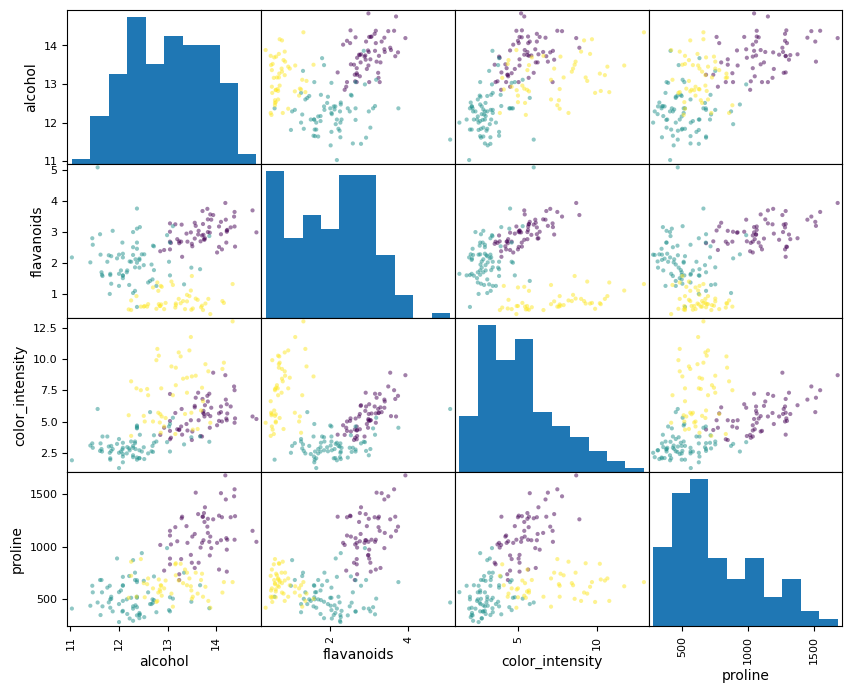

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

cols = ["alcohol", "flavanoids", "color_intensity", "proline"]
pd.plotting.scatter_matrix(df[cols], c=df["target"], figsize=(10, 8))
plt.show()

> **Nota docente** — pregunta guía: *¿se pueden separar las clases a ojo?*  
> En algunos pares (flavanoids vs proline) bastante bien; en otros se mezclan.  
> De ahí sale el concepto informal de **separabilidad**: si un humano puede trazar la frontera
> mirando el gráfico, un modelo simple probablemente también puede.

---
## Bloque 8 · 13:05-13:40 · El gancho: modelo end-to-end

### 7. Modelo en 5 líneas · 13:05-13:20 (15 min)

**Sin explicar el algoritmo.** Solo la mecánica `fit → predict → score`.
**Cada estudiante elige** uno de los dos modelos — y debe **justificar por qué eligió ese**
(los conocen de Minería de Datos).

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

X, y = df.iloc[:, :-1], df["target"]

# Opción A
knn = KNeighborsClassifier()
knn.fit(X, y)
print("KNN  :", knn.score(X, y))

# Opción B
arbol = DecisionTreeClassifier(random_state=0)
arbol.fit(X, y)
print("Árbol:", arbol.score(X, y))

KNN  : 0.7865168539325843
Árbol: 1.0


In [11]:
# Una predicción sobre una muestra concreta
print("predicción :", arbol.predict(X.iloc[[0]]))
print("clase real :", y.iloc[0])

predicción : [0]
clase real : 0


> **Nota docente** — marcar el momento:  
> *"welcome back al ML — ya entrenaron modelos en Minería de Datos; ahora vamos a entender de
> verdad qué pasa ahí dentro."*  
>
> Con 4-5 estudiantes habrá de ambos modelos, y el contraste es oro pedagógico:
> 1. Se evalúa **sobre los mismos datos de entrenamiento** — a propósito. **No corregirlo todavía.**
> 2. **KNN ~0.79:** aun haciendo trampa, mediocre — sufre con las escalas dispares que vieron en
>    `describe()` (proline ~750 domina las distancias). No explicarlo aún: dejarlo como pregunta.
> 3. **Árbol 1.0:** ¿100%? ¿Es este modelo "mejor", o memorizó los datos? → sobreajuste, sin
>    nombrarlo todavía.
> 4. Confrontar entre ellos las justificaciones de la elección **antes** de pasar a la discusión.

### 8. Discusión dirigida: ¿por qué esto no basta? · 13:20-13:30 (10 min)

Preguntas para levantar — **dejar que ellos lleguen**, no dar la respuesta. A la derecha, hacia
dónde apunta cada una:

| Pregunta al curso | Hacia dónde apunta |
|---|---|
| ¿Esos scores son creíbles? ¿Con qué datos los medimos? | **train-test split** (clase 5) |
| ¿Por qué el árbol sacó 100% y KNN 79% con los mismos datos? ¿Cuál es "mejor"? | sobreajuste y comparación honesta de modelos (**U2/U3**) |
| ¿Por qué KNN, ni siquiera haciendo trampa, acierta más? ¿Tendrán algo que ver las escalas de `describe()`? | **preprocesamiento / escalamiento** (clase 3) |
| ¿Qué pasa si llega un vino con un valor faltante o medido en otra unidad? | **preprocesamiento** (clase 3) |
| ¿Cómo eligió el modelo? ¿Qué hay dentro de `fit`? | **Unidad 2** |
| ¿Y si las features fueran 10.000? | **selección/extracción de características** (clase 4) |

**Cierre de la discusión:** *"todo lo que acaban de dudar es exactamente el programa de la Unidad 1."*

### 9. Sistema de tareas y cierre · 13:30-13:40 (10 min)

- Explicar la evaluación práctica: **3 tareas en el semestre** (25% de la NF como promedio),
  enviadas por el profesor, cada una condensando lo visto en clases hasta ese punto. Fechas
  tentativas alineadas con los cierres de contenido antes de cada certamen.
- **Ejercicio propuesto (no evaluado):** repetir el flujo completo de hoy con otro dataset de
  `sklearn.datasets` (`load_iris` o `load_breast_cancer`) — cargar, explorar, visualizar, entrenar
  y preguntarse: *¿por qué el score obtenido no es una medida honesta del modelo?* Calentamiento
  para la Tarea 1.
- Recordar qué viene la próxima clase: **12-ago**, tipos de aprendizaje en profundidad (lab de la
  tarde suspendido por Días Sansanos).

---
### Anexo — solución del ejercicio propuesto (no mostrar en clase)

Mismo flujo sobre `breast_cancer`, para tenerlo a mano si alguien pregunta.

In [12]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer(as_frame=True).frame
Xb, yb = bc.iloc[:, :-1], bc["target"]

print(bc.shape, bc["target"].value_counts().to_dict())
print("KNN  :", KNeighborsClassifier().fit(Xb, yb).score(Xb, yb))
print("Árbol:", DecisionTreeClassifier(random_state=0).fit(Xb, yb).score(Xb, yb))
# Mismo fenómeno: el árbol llega a 1.0 sobre sus propios datos de entrenamiento
# y KNN, sin escalar, se queda por debajo.

(569, 31) {1: 357, 0: 212}
KNN  : 0.9472759226713533
Árbol: 1.0
